# Lion Nose Color

Can you estimate a lion's age from a photograph of its nose?

Lions are born with pink noses that gradually darken with age, developing black freckles until they eventually turn completely black.

The dataset `lion-nose-color.csv` contains data on 91 lions from the Serengeti, each monitored by researchers since birth. Because their exact ages are known, researchers can analyze photographs to determine the percentage of black on their noses and assess how well nose coloration predicts age.

In [25]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'lion-nose-color.csv' and 'linear_model.py'.

# from google.colab import files
# uploaded = files.upload()

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel
from sklearn.linear_model import LinearRegression
import numpy as np

df = pd.read_csv('lion-nose-color.csv')
df.head()

,age,proportion_black
0,1.10,21.1
1,4.19,34.9
2,1.91,26.8
3,8.16,84.8
4,7.32,47.9


# Project Ideas

- Create a linear regression model to predict `age` from `proportion_black`

- Use the model to estimate a lion's age when its nose is 50% black. 

#### Considerations
- Can you determine a lion's age when its nose is 100% black? Why or why not?

In [27]:
# YOUR CODE HERE (add additional cells as needed)

# Linear model API

# linear = LinearModel()
# linear.fit(x, y)
# linear.predict(x)
# linear.plot_model(x_min, x_max, color="black")
# linear.print_model_info(self):


In [28]:
X = df[["proportion_black"]]
y = df["age"]


In [29]:

# ---------------------------------------------------
# CREATE MODEL
# ---------------------------------------------------
model = LinearRegression()

model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:

# ---------------------------------------------------
# PREDICT AGE FOR 50% BLACK NOSE
# ---------------------------------------------------
nose_50 = pd.DataFrame({
    "proportion_black": [0.5]
})

predicted_age_50 = model.predict(nose_50)[0]

print("\nPREDICTED AGE")
print("-" * 30)

print(
    f"A lion with a nose that is 50% black "
    f"is predicted to be "
    f"{predicted_age_50:.2f} years old."
)



PREDICTED AGE
------------------------------
A lion with a nose that is 50% black is predicted to be 1.53 years old.


In [31]:

# ---------------------------------------------------
# REGRESSION LINE
# ---------------------------------------------------
x_range = np.linspace(0, 1, 300).reshape(-1, 1)

y_range = model.predict(x_range)


d:\harsh\cisco\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


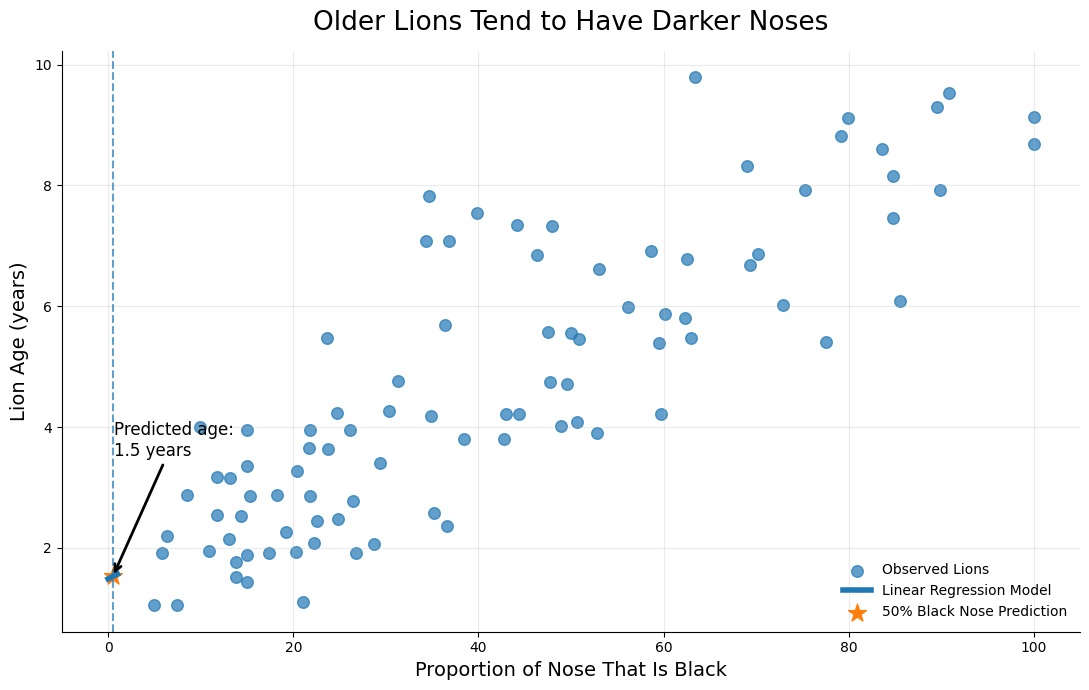

In [32]:

# ---------------------------------------------------
# VISUALIZATION (FOLLOWING PRO TIPS)
# ---------------------------------------------------

plt.figure(figsize=(11, 7))

# Scatter plot
plt.scatter(
    df["proportion_black"],
    df["age"],
    s=70,
    alpha=0.7,
    label="Observed Lions"
)

# Regression line
plt.plot(
    x_range,
    y_range,
    linewidth=4,
    label="Linear Regression Model"
)

# Highlight 50% prediction
plt.scatter(
    [0.5],
    [predicted_age_50],
    s=180,
    marker="*",
    label="50% Black Nose Prediction"
)

# Reference line
plt.axvline(
    0.5,
    linestyle="--",
    alpha=0.7
)

# Annotation
plt.annotate(
    f"Predicted age:\n{predicted_age_50:.1f} years",
    
    xy=(0.5, predicted_age_50),
    
    xytext=(0.62, predicted_age_50 + 2),

    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),

    fontsize=12
)

plt.title(
    "Older Lions Tend to Have Darker Noses",
    fontsize=19,
    pad=15
)

plt.xlabel(
    "Proportion of Nose That Is Black",
    fontsize=14
)

plt.ylabel(
    "Lion Age (years)",
    fontsize=14
)

plt.grid(alpha=0.25)

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()


In [35]:

# ---------------------------------------------------
# 100% BLACK NOSE CONSIDERATION
# ---------------------------------------------------

nose_100 = pd.DataFrame({
    "proportion_black": [1.0]
})

predicted_age_100 = model.predict(nose_100)[0]

print("\n100% BLACK NOSE")
print("-" * 30)

print(
    f"Predicted age at 100% black nose: "
    f"{predicted_age_100:.2f} years"
)

print(
    "\nHowever, this prediction may not be reliable "
    "if the dataset contains very few lions with "
    "completely black noses."
)


100% BLACK NOSE
------------------------------
Predicted age at 100% black nose: 1.57 years

However, this prediction may not be reliable if the dataset contains very few lions with completely black noses.
